In [4]:
# Imports

import pyglet
pyglet.options["headless"] = True


import warp as wp

import numpy as np
import pickle


from src import simulator, render
from importlib import reload

from sklearn.preprocessing import MinMaxScaler
from tqdm import trange

import pyvista as pv
import os


# Configure these according to your system, see the PyVista page for details
# Alternatively, just replace the backend to be 'html'

# pv.global_theme.trame.jupyter_extension_enabled = True
# pv.global_theme.trame.server_proxy_enabled = False
# os.environ["PYVISTA_OFF_SCREEN"] = "true"
pv.set_jupyter_backend('static')  # change this to html for better experience



def fibonacci_sphere_points(num_points, radius):
    points = np.zeros((num_points, 3))
    phi = np.pi * (3. - np.sqrt(5.))

    for i in range(num_points):
        y = 1 - (i / float(num_points - 1)) * 2 
        r = np.sqrt(1 - y * y) 
        theta = phi * i 

        x = np.cos(theta) * r
        z = np.sin(theta) * r

        points[i] = [x * radius, y * radius, z * radius]

    return points


def uniform_ball_points(n, R):
    v = np.random.normal(size=(n, 3))
    v /= np.linalg.norm(v, axis=1, keepdims=True)
    radii = (np.random.rand(n) ** (1/3)) * R  # uniform in volume
    return v * radii[:, None]


def save_state(centers, radii, radii_eq, activators, inhibitors, particle_count, fname):
    with open(f'Checkpoints/{fname}.pkl', 'wb') as f:
        pickle.dump((centers, radii, radii_eq, activators, inhibitors, particle_count), f)


def load_state(fname):
    with open(f'Checkpoints/{fname}.pkl', 'rb') as f:
        state = pickle.load(f)

    return state

wp.init()
wp.clear_kernel_cache()
wp.clear_lto_cache()


## Setup

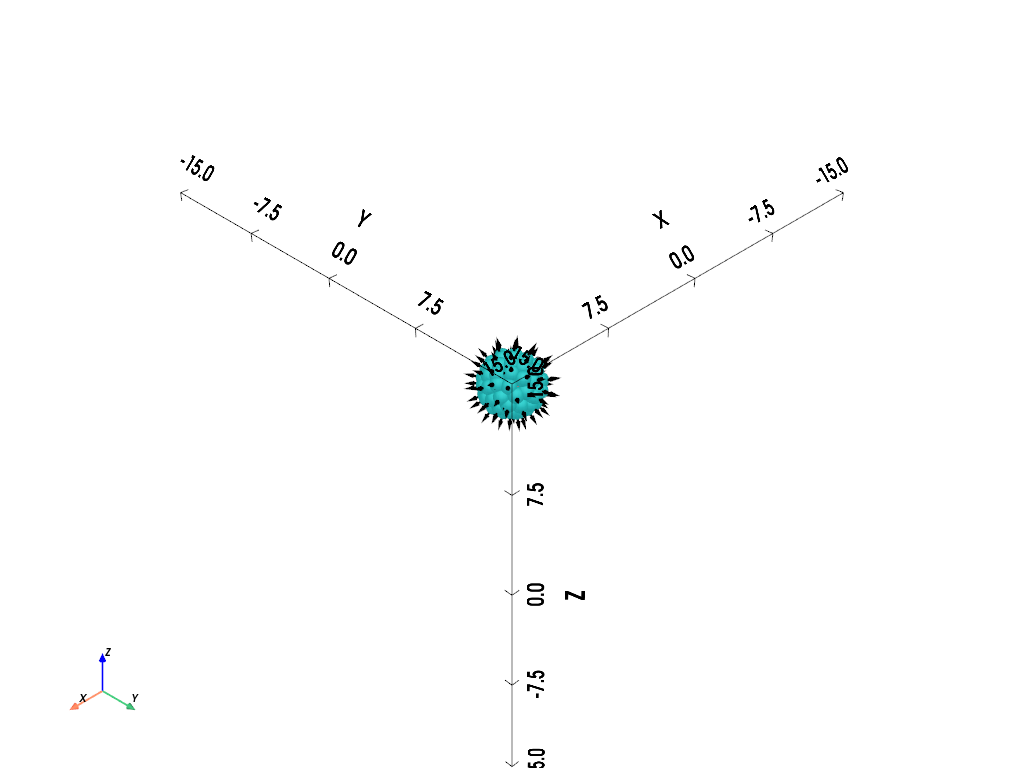

In [5]:
# Sample points in space
particle_count = 100
max_particles = 5000
centers, radii, radii_eq, activators, inhibitors = np.full((max_particles, 3), np.array([0.,0.,0.])), np.full((max_particles,), -1000.), np.full((max_particles,), -1000.), np.full((max_particles,), 0.), np.full((max_particles,), 0.)

rad_proto = np.full((particle_count,), 0.6) 

radii[:particle_count] = rad_proto
radii_eq[:particle_count] = rad_proto


# Chemicals
act_mu = (((rad_proto**3) * 0.75) / 2.).mean()
inhib_mu = (((rad_proto**3) * 0.75) / 10.).mean()
act_sigma, inhib_sigma = 0.001, 0.001


activators[:particle_count] = act_mu + act_sigma * np.random.normal(size=(particle_count,))
inhibitors[:particle_count] = inhib_mu + inhib_sigma * np.random.normal(size=(particle_count,))


# CENTERS
prop = 4.

N_mes = int(particle_count / prop)
N_epi = particle_count - N_mes

R_shell = 2.0
R_inner = R_shell - 0.65  # ~1.35 when R_shell=2.0

centers[:N_mes] = uniform_ball_points(N_mes, R_inner)
centers[N_mes:particle_count] = fibonacci_sphere_points(N_epi, R_shell)

centers[:particle_count] += 0.05 * np.random.normal(size=(particle_count, 3))


# polarities
polarities = np.ones((max_particles, 3), dtype=np.float64) / np.sqrt(3)
vesicle_center = centers[:particle_count].mean(axis=0)


p = centers[:particle_count] - vesicle_center
norms = np.linalg.norm(p, axis=1, keepdims=True)
polarities[:particle_count] = p / np.clip(norms, 1e-12, None)

# cell types
cell_types = np.full((max_particles,), 3, dtype=np.uint32)
cell_types[:N_mes] = 0
cell_types[N_mes:particle_count] = 1


plotter = render.PyVistaInterface.draw_3d_view(centers, radii, MinMaxScaler(feature_range=(0, 0.9)).fit_transform((activators * 0.75 / (radii**3)).reshape(-1,1)).flatten(), polarities, particle_count, blim=-15, tlim=15, alpha=1, polarity_length=3., cell_types=cell_types)
plotter.show()

## Polarize

In [6]:
R = wp.from_numpy(radii,   dtype=wp.float32, device="cuda")
X = wp.from_numpy(centers, dtype=wp.vec3f, device="cuda")
P = wp.from_numpy(polarities, dtype=wp.vec3f, device="cuda")
CT = wp.from_numpy(cell_types, dtype=wp.uint32, device="cuda")

X_pass = wp.zeros_like(X, device="cuda")

for i in trange(1000):
    simulator.mech_step_sticky(X, R, P, CT, particle_count, dt_mech, X_pass, P, grad_consist=False)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:00<00:00, 3361.93it/s]

Module src.simulator e840196 load on device 'cuda:0' took 191.92 ms  (compiled)


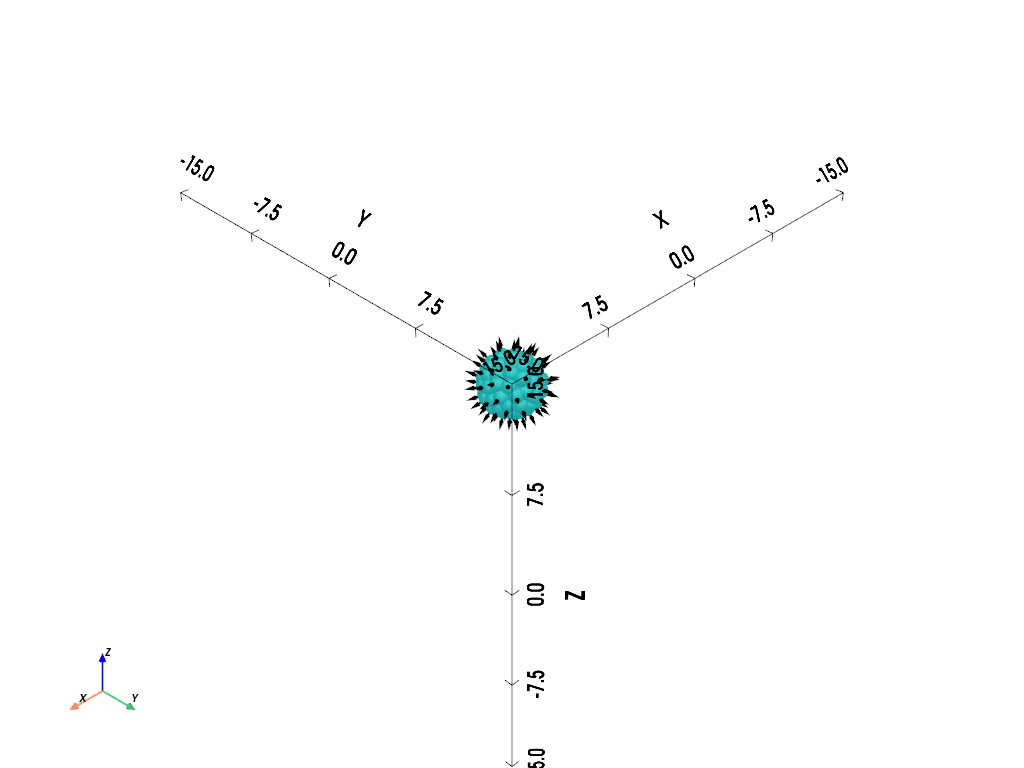

In [8]:
plotter = render.PyVistaInterface.draw_3d_view(X.numpy(), R.numpy(), MinMaxScaler(feature_range=(0, 0.9)).fit_transform((activators * 0.75 / (radii**3)).reshape(-1,1)).flatten(), P.numpy(), particle_count, blim=-15, tlim=15, alpha=1, polarity_length=3., cell_types=CT.numpy())
plotter.show()

## Move

In [9]:
R = wp.from_numpy(radii,   dtype=wp.float32, device="cuda")
X = wp.from_numpy(centers, dtype=wp.vec3f, device="cuda")
P = wp.from_numpy(polarities, dtype=wp.vec3f, device="cuda")
CT = wp.from_numpy(cell_types, dtype=wp.uint32, device="cuda")


for t in trange(30000):
    simulator.mech_step_sticky(X, R, P, CT, particle_count, dt_mech, X, P, grad_consist=False)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 30000/30000 [00:02<00:00, 10160.35it/s]


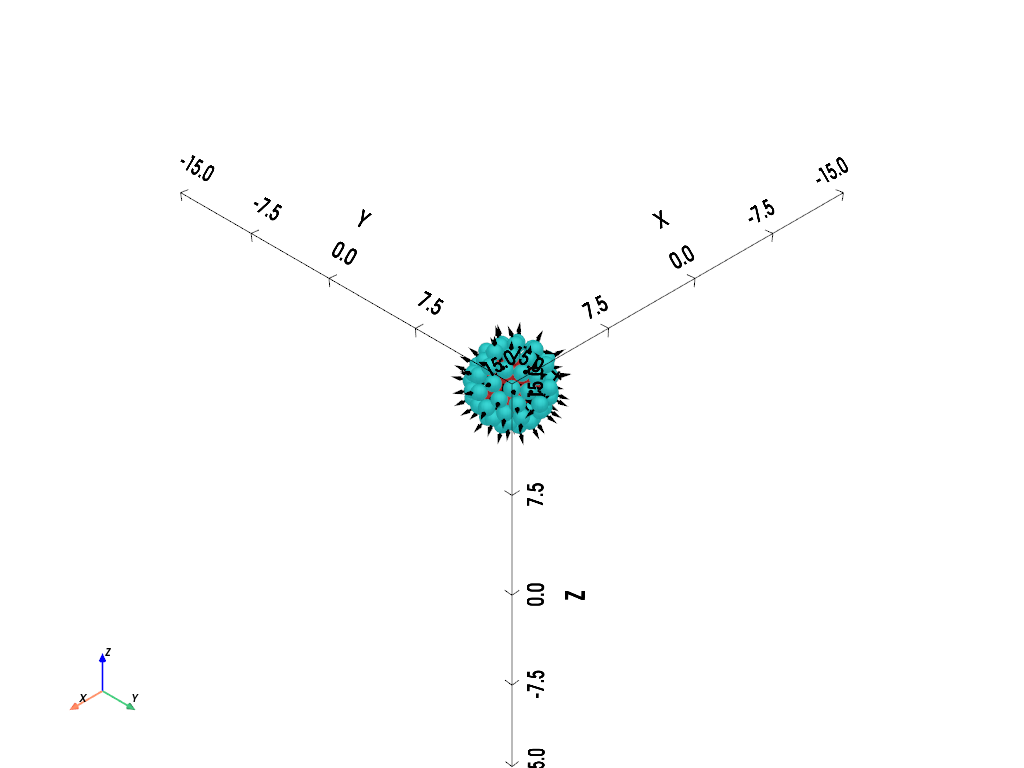

In [10]:
plotter = render.PyVistaInterface.draw_3d_view(X.numpy(), R.numpy(), MinMaxScaler(feature_range=(0, 0.9)).fit_transform((activators * 0.75 / (radii**3)).reshape(-1,1)).flatten(), P.numpy(), particle_count, blim=-15, tlim=15, alpha=1, polarity_length=3., cell_types=CT.numpy())
plotter.show()

## Chemicals

In [15]:
A = wp.from_numpy(activators,   dtype=wp.float32, device="cuda")
I = wp.from_numpy(inhibitors, dtype=wp.float32, device="cuda")
R = wp.from_numpy(radii,   dtype=wp.float32, device="cuda")
X = wp.from_numpy(centers, dtype=wp.vec3f, device="cuda")
P = wp.from_numpy(polarities, dtype=wp.vec3f, device="cuda")
CT = wp.from_numpy(cell_types, dtype=wp.uint32, device="cuda")

S = wp.full(1, value=1e-2, dtype=wp.float32)
T = wp.full(1, value=1e-2, dtype=wp.float32)
phi = 10.

dt_chem=1e-1

lapA, lapI = wp.zeros_like(A, device="cuda"), wp.zeros_like(I, device="cuda")

a_s, i_s = [], []

for i in trange(10000):
    simulator.mech_step_sticky(X, R, P, CT, particle_count, dt_mech, X, P, grad_consist=False)

for t in trange(50000):
    lapA.zero_()
    lapI.zero_()
    
    simulator.chem_step(A, I, X, R, lapA, lapI, S, T, phi, dt_chem, particle_count, A, I, grad_consist=False)
    
    a_s.append(A.numpy())
    i_s.append(I.numpy())

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 50000/50000 [00:07<00:00, 6918.91it/s]


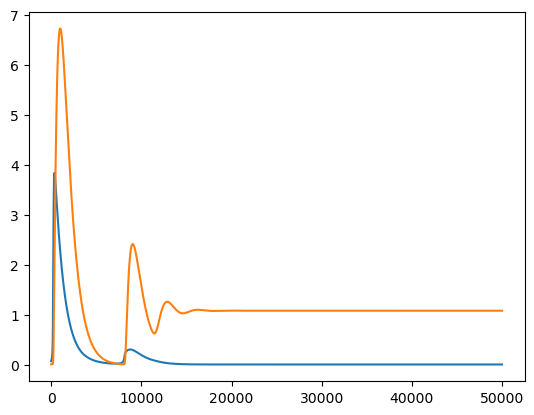

In [16]:
import matplotlib.pyplot as plt
plt.plot([a_s[i][0] for i in range(len(a_s))])
plt.plot([i_s[i][0] for i in range(len(i_s))])

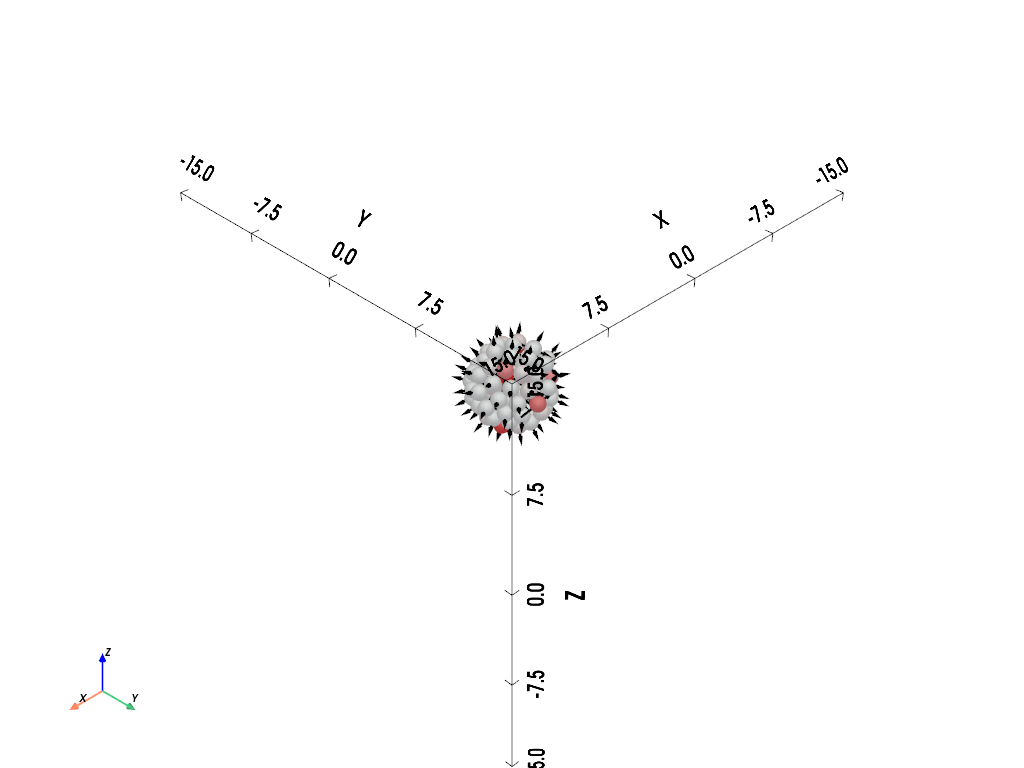

In [17]:
plotter = render.PyVistaInterface.draw_3d_view(X.numpy(), R.numpy(), MinMaxScaler(feature_range=(0, 0.9)).fit_transform((A.numpy() * 0.75 / (R.numpy()**3)).reshape(-1,1)).flatten(), P.numpy(), particle_count, blim=-15, tlim=15, alpha=1, polarity_length=3.)
plotter.show()

## Growth

In [27]:
A = wp.from_numpy(activators,   dtype=wp.float32, device=device)
I = wp.from_numpy(inhibitors, dtype=wp.float32, device=device)
R = wp.from_numpy(radii,   dtype=wp.float32, device=device)
R_eq = wp.from_numpy(radii_eq,   dtype=wp.float32, device=device)
X = wp.from_numpy(centers, dtype=wp.vec3f, device=device)
P = wp.from_numpy(polarities, dtype=wp.vec3f, device="cuda")
CT = wp.from_numpy(cell_types, dtype=wp.uint32, device="cuda")

SC = wp.full(1, value=1e-1, dtype=wp.float32, requires_grad=True)
AP = wp.full(1, value=10., dtype=wp.float32, requires_grad=True)
R_ref = 0.60   # epithelial target radius
R_max = 0.85   # mes eq radius cap 

keys = simulator.gen_key_array(max_particles)

dt_growth = 1e-2 


for i in trange(10000):
    simulator.mech_step_sticky(X, R, P, CT, particle_count, dt_mech, X, P, grad_consist=False)


for t in trange(20000):
    simulator.mech_step_sticky(X, R, P, CT, particle_count, dt_mech, X, P, grad_consist=False)
    simulator.growth_step(R, R_eq, A, CT, keys, AP, SC, dt_growth, R_ref, R_max, pcount, R, R_eq, grad_consist=False)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20000/20000 [00:02<00:00, 7713.06it/s]


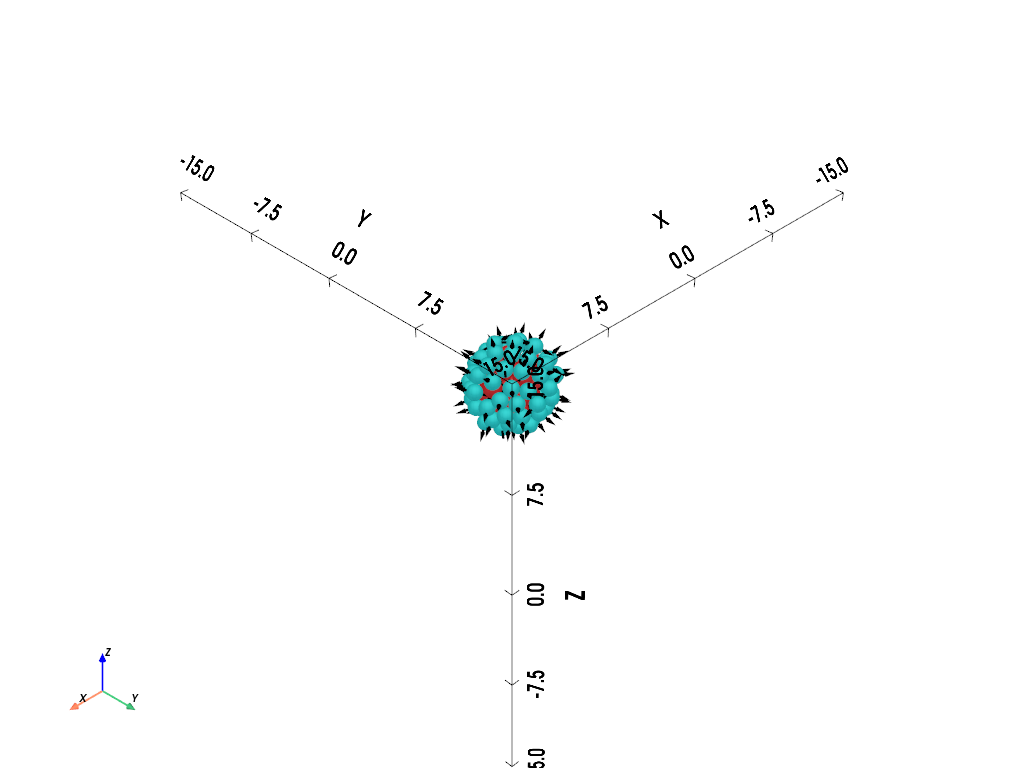

In [24]:
plotter = render.PyVistaInterface.draw_3d_view(X.numpy(), R.numpy(), MinMaxScaler(feature_range=(0, 0.9)).fit_transform((A.numpy() * 0.75 / (R.numpy()**3)).reshape(-1,1)).flatten(), P.numpy(), particle_count, blim=-15, tlim=15, alpha=1, polarity_length=3., cell_types=CT.numpy())
plotter.show()

## Render - Full with division

In [132]:
from ipywidgets import IntProgress
from IPython.display import display

device="cuda"

A = wp.from_numpy(activators,   dtype=wp.float32, device=device)
I = wp.from_numpy(inhibitors, dtype=wp.float32, device=device)
R = wp.from_numpy(radii,   dtype=wp.float32, device=device)
R_eq = wp.from_numpy(radii_eq,   dtype=wp.float32, device=device)
X = wp.from_numpy(centers, dtype=wp.vec3f, device=device)
P = wp.from_numpy(polarities, dtype=wp.vec3f, device="cuda")
CT = wp.from_numpy(cell_types, dtype=wp.uint32, device="cuda")


# Buffers and keys
lapA, lapI = wp.zeros_like(A, device="cuda"), wp.zeros_like(I, device="cuda")
keys = simulator.gen_key_array(max_particles)
n_tot = wp.zeros(shape=max_particles, dtype=wp.int32, device=device)
n_epi = wp.zeros(shape=max_particles, dtype=wp.int32, device=device)
n_mes = wp.zeros(shape=max_particles, dtype=wp.int32, device=device)
surface = wp.zeros(shape=max_particles, dtype=wp.uint32, device=device)
pcount=particle_count


# Generic constants
dt_mech = 5e-2
dt_chem = 5e-2
dt_growth = 1e-2 

R_ref = 0.60   # epithelial target radius (as you have)
R_max = 0.85   # mes eq radius cap (your 0.8 is fine too)
R_div_ref = 0.70   # slightly above R_ref so mes has to grow before dividing

i=1.
tau=1.
tmax=1.
phi=10.

# Cell type constants
surf_thresh = 9    # 9–10 is a good starting band
epi_max_neighbors = 4    # tighter than 10 to discourage multilayering
suppress_mes_surface = 1
p_epi = 1e-2 # try 2e-3, then 5e-3 if epi can’t keep up

    
SC = wp.full(1, value=0.15, dtype=wp.float32, requires_grad=True)
AP = wp.full(1, value=10., dtype=wp.float32, requires_grad=True)
S = wp.full(1, value=5e-2, dtype=wp.float32)
T = wp.full(1, value=1e-2, dtype=wp.float32)

render_stride = 5

for t in trange(10000):
    simulator.mech_step_sticky(X, R, P, CT, particle_count, dt_mech, X, P, grad_consist=False)


for t in trange(200000):
    lapA.zero_()
    lapI.zero_()
    # PDEs
    simulator.chem_step(A, I, X, R, lapA, lapI, S, T, phi, dt_chem, particle_count, A, I, grad_consist=False)



with render.WarpMovieRenderer(
    filename="Output/Turing/full_polarization_epi_2.mp4",
    max_particles=max_particles,
    width=1920,
    height=1080,
    fps=60,
    device="cuda",
    camera_pos=(0., 0., 50.),
    camera_front=(0.0, 0.0, -1.0),
    camera_up=(0.0, 1.0, 0.0),
) as mov:

    for t in trange(2600):
        lapA.zero_()
        lapI.zero_()
    
        # PDEs
        simulator.mech_step_sticky(X, R, P, CT, pcount, dt_mech, X, P, grad_consist=False)
        simulator.chem_step(A, I, X, R, lapA, lapI, S, T, phi, dt_chem, pcount, A, I, grad_consist=False)
        simulator.growth_step(R, R_eq, A, CT, keys, AP, SC, dt_growth, R_ref, R_max, pcount, R, R_eq, grad_consist=False)
    
        # Buffers
        n_tot.zero_()
        n_epi.zero_()
        n_mes.zero_()
        
        # counts
        wp.launch(
            simulator.count_neighbors,
            dim=(pcount, pcount),
            inputs=[X, R, CT],
            outputs=[n_tot, n_epi, n_mes],
            device=device,
        )
        
        # surface flag
        wp.launch(
            simulator.classify_surface,
            dim=pcount,
            inputs=[n_tot, surface, surf_thresh],
            device=device,
        )
        
        # Divide
        div_count = wp.full(1, value=pcount, dtype=wp.int32, device=device)
        div_slots = wp.full(pcount, value=-1, dtype=wp.int32, device=device)
        
                
        wp.launch(
            simulator.division_losses,
            dim=pcount,
            inputs=[
                X, R, CT, keys,
                n_epi, n_mes, surface,
                div_count, div_slots,
                R_div_ref, p_epi, epi_max_neighbors, suppress_mes_surface,
                i, tmax, tau,
                max_particles
            ],
            device=device,
        )
        
        
        wp.launch(
            simulator.division_logic,
            dim=pcount,
            inputs=[
                X, R, R_eq, A, I,
                P, CT, div_slots,
            ],
            device=device,
        )
                
        pcount = min(div_count.numpy().item(), max_particles)
            
    
        if (t % render_stride) == 0:
            mov.write_frame_from_state(
                t=t,
                centers_wp=X,
                radii_wp=R,
                A_wp=A,
                I_wp=I,
                particle_count=int(pcount),
                morph="ratio",          # "A" or "I" or "ratio"
                morph_scale=1.,   
                hue=0.80,
            )


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2600/2600 [00:08<00:00, 297.35it/s]


In [133]:
X.numpy().min()

np.float32(-9.825011)

In [134]:
np.unique(CT.numpy(), return_counts=True)

(array([0, 1, 3], dtype=uint32), array([2227,  577, 2196]))

In [135]:
pcount

2804

In [136]:
R.numpy().max()

np.float32(0.7685717)

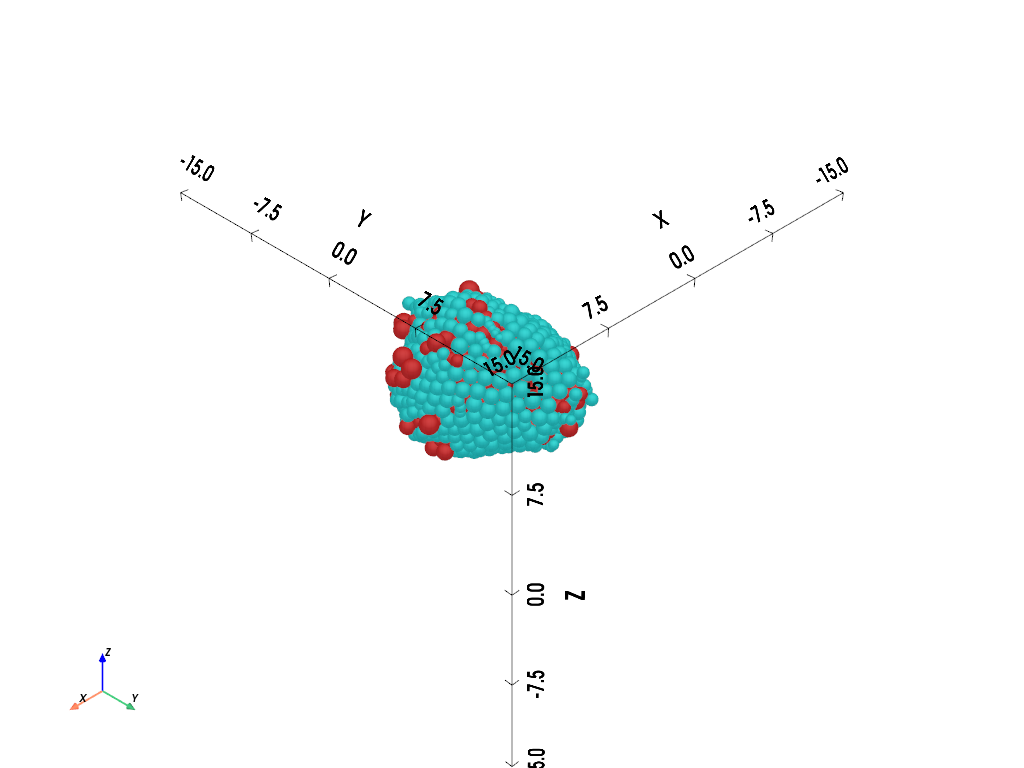

In [137]:
# almost smooth ball, even though the polarity isn't fully embedded yet

plotter = render.PyVistaInterface.draw_3d_view(X.numpy(), R.numpy(), MinMaxScaler(feature_range=(0, 0.9)).fit_transform((A.numpy() * 0.75 / (R.numpy()**3)).reshape(-1,1)).flatten(), P.numpy(), pcount, blim=-15, tlim=15, alpha=1, polarity_length=0., cell_types=CT.numpy())
plotter.show()

In [ ]:
from IPython.display import Video
Video("Output/Turing/full_polarization_epi_2.mp4", embed=True)